In [2]:
pth = r'/home/zzj/projects/FTSAD/supp_files/latency_case_data_processed.csv'

import pandas as pd
data = pd.read_csv(pth)
print(data.shape)

(4950, 8)


In [3]:
import re
def case_name_split(case_name_list):
    pattern = r'(\w+)k-(\w+)seg-(\w+)'
    case_name_split_list = []
    for case_name in case_name_list:
        match = re.match(pattern, case_name)
        if match:
            case_split = match.groups()
            case_split = [int(case_split[0])*1000, int(case_split[1]), case_split[2]]
            case_name_split_list.append(case_split)
        else:
            print(f"Pattern not matched for {case_name}")
    return case_name_split_list

case_name_list = data['case_name']
case_name_split_list = case_name_split(case_name_list)
case_data = pd.DataFrame(case_name_split_list, columns=['ts_len', 'seg', 'seg_type'])
# merge the new columns with the original data
data_new = pd.concat([data, case_data], axis=1)
data_new = data_new[data_new['model_name'] != 'Random']
print(data_new.shape)

# 排序，按照seg_type: 先比前面的数字，然后L，H的顺序
def sort_seg_type_key(tmp):
    idx = tmp[:-1]    
    typ = tmp[-1]
    return (int(idx), 0 if typ == 'L' else 1)

seg_type_key_list = [
    '20L', '20H', '50L', '50H', '100L', '100H', '500L', '500H',
]

metric_sort = [
  "F1",
  "F1-PA",
  "Reduced-F1",
  "PA%K",
  "R-based F1",
  "TaPR",
  "eTaPR",
  "Aff-F1",
  "NAff-F1",
  "UAff-F1",
  "PATE",
  "AUC-ROC",
  "AUC-PR",
  "VUS-ROC",
  "VUS-PR"
]

def sort_metric_key(tmp):
    idx = metric_sort.index(tmp)
    return idx


print(data_new.head())
print(data_new.columns)

(4500, 11)
          case_name model_name  case_seed metric_name  mean_val   std_val  \
0  100k-100seg-100H    Model10         53      AUC-PR  0.049182  0.000087   
1  100k-100seg-100H    Model10         53     AUC-ROC  0.100225  0.002738   
2  100k-100seg-100H    Model10         53      Aff-F1  0.599683  0.008507   
3  100k-100seg-100H    Model10         53          F1  0.007339  0.000856   
4  100k-100seg-100H    Model10         53       F1-PA  0.511857  0.041889   

   mean_latency  std_latency  ts_len  seg seg_type  
0     21.221560     0.059661  100000  100     100H  
1     28.568022     0.162600  100000  100     100H  
2    808.004104     2.556749  100000  100     100H  
3     38.742157     0.227650  100000  100     100H  
4     99.825350     0.573268  100000  100     100H  
Index(['case_name', 'model_name', 'case_seed', 'metric_name', 'mean_val',
       'std_val', 'mean_latency', 'std_latency', 'ts_len', 'seg', 'seg_type'],
      dtype='object')


In [3]:
# todo
# import matplotlib.pyplot as plt
# import seaborn as sns
# # 1. 相同长度下，不同指标的latency分布图
# def plot_latency_distribution(data, ts_len):
    

#     filtered_data = data[data['ts_len'] == ts_len]
#     metric_names = filtered_data['metric_name'].unique()
#     for metric in metric_names:
#         metric_data = filtered_data[filtered_data['metric_name'] == metric]
#         metric_data = metric_data.sort_values(by=['seg_type'], key=lambda x: x.apply(sort_seg_type_key))
#         # metric_latency = metric_data['mean_latency']
#         plt.figure(figsize=(4, 6))
#         sns.boxplot(x='seg_type', y='mean_latency', data=metric_data)
#         plt.title(f'Latency Distribution for ts_len = {ts_len}, Metric = {metric}')
#         plt.xlabel('Segment Type')
#         plt.ylabel('Latency')
#         plt.xticks(rotation=45)
#         plt.tight_layout()
#         plt.show()

# plot_latency_distribution(data_new, 10000)  # Example for ts_len = 1000


/tmp/ipykernel_3934155/16273882.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  custom_palette = cm.get_cmap('tab10').colors[:len(seg_type_key_list)]


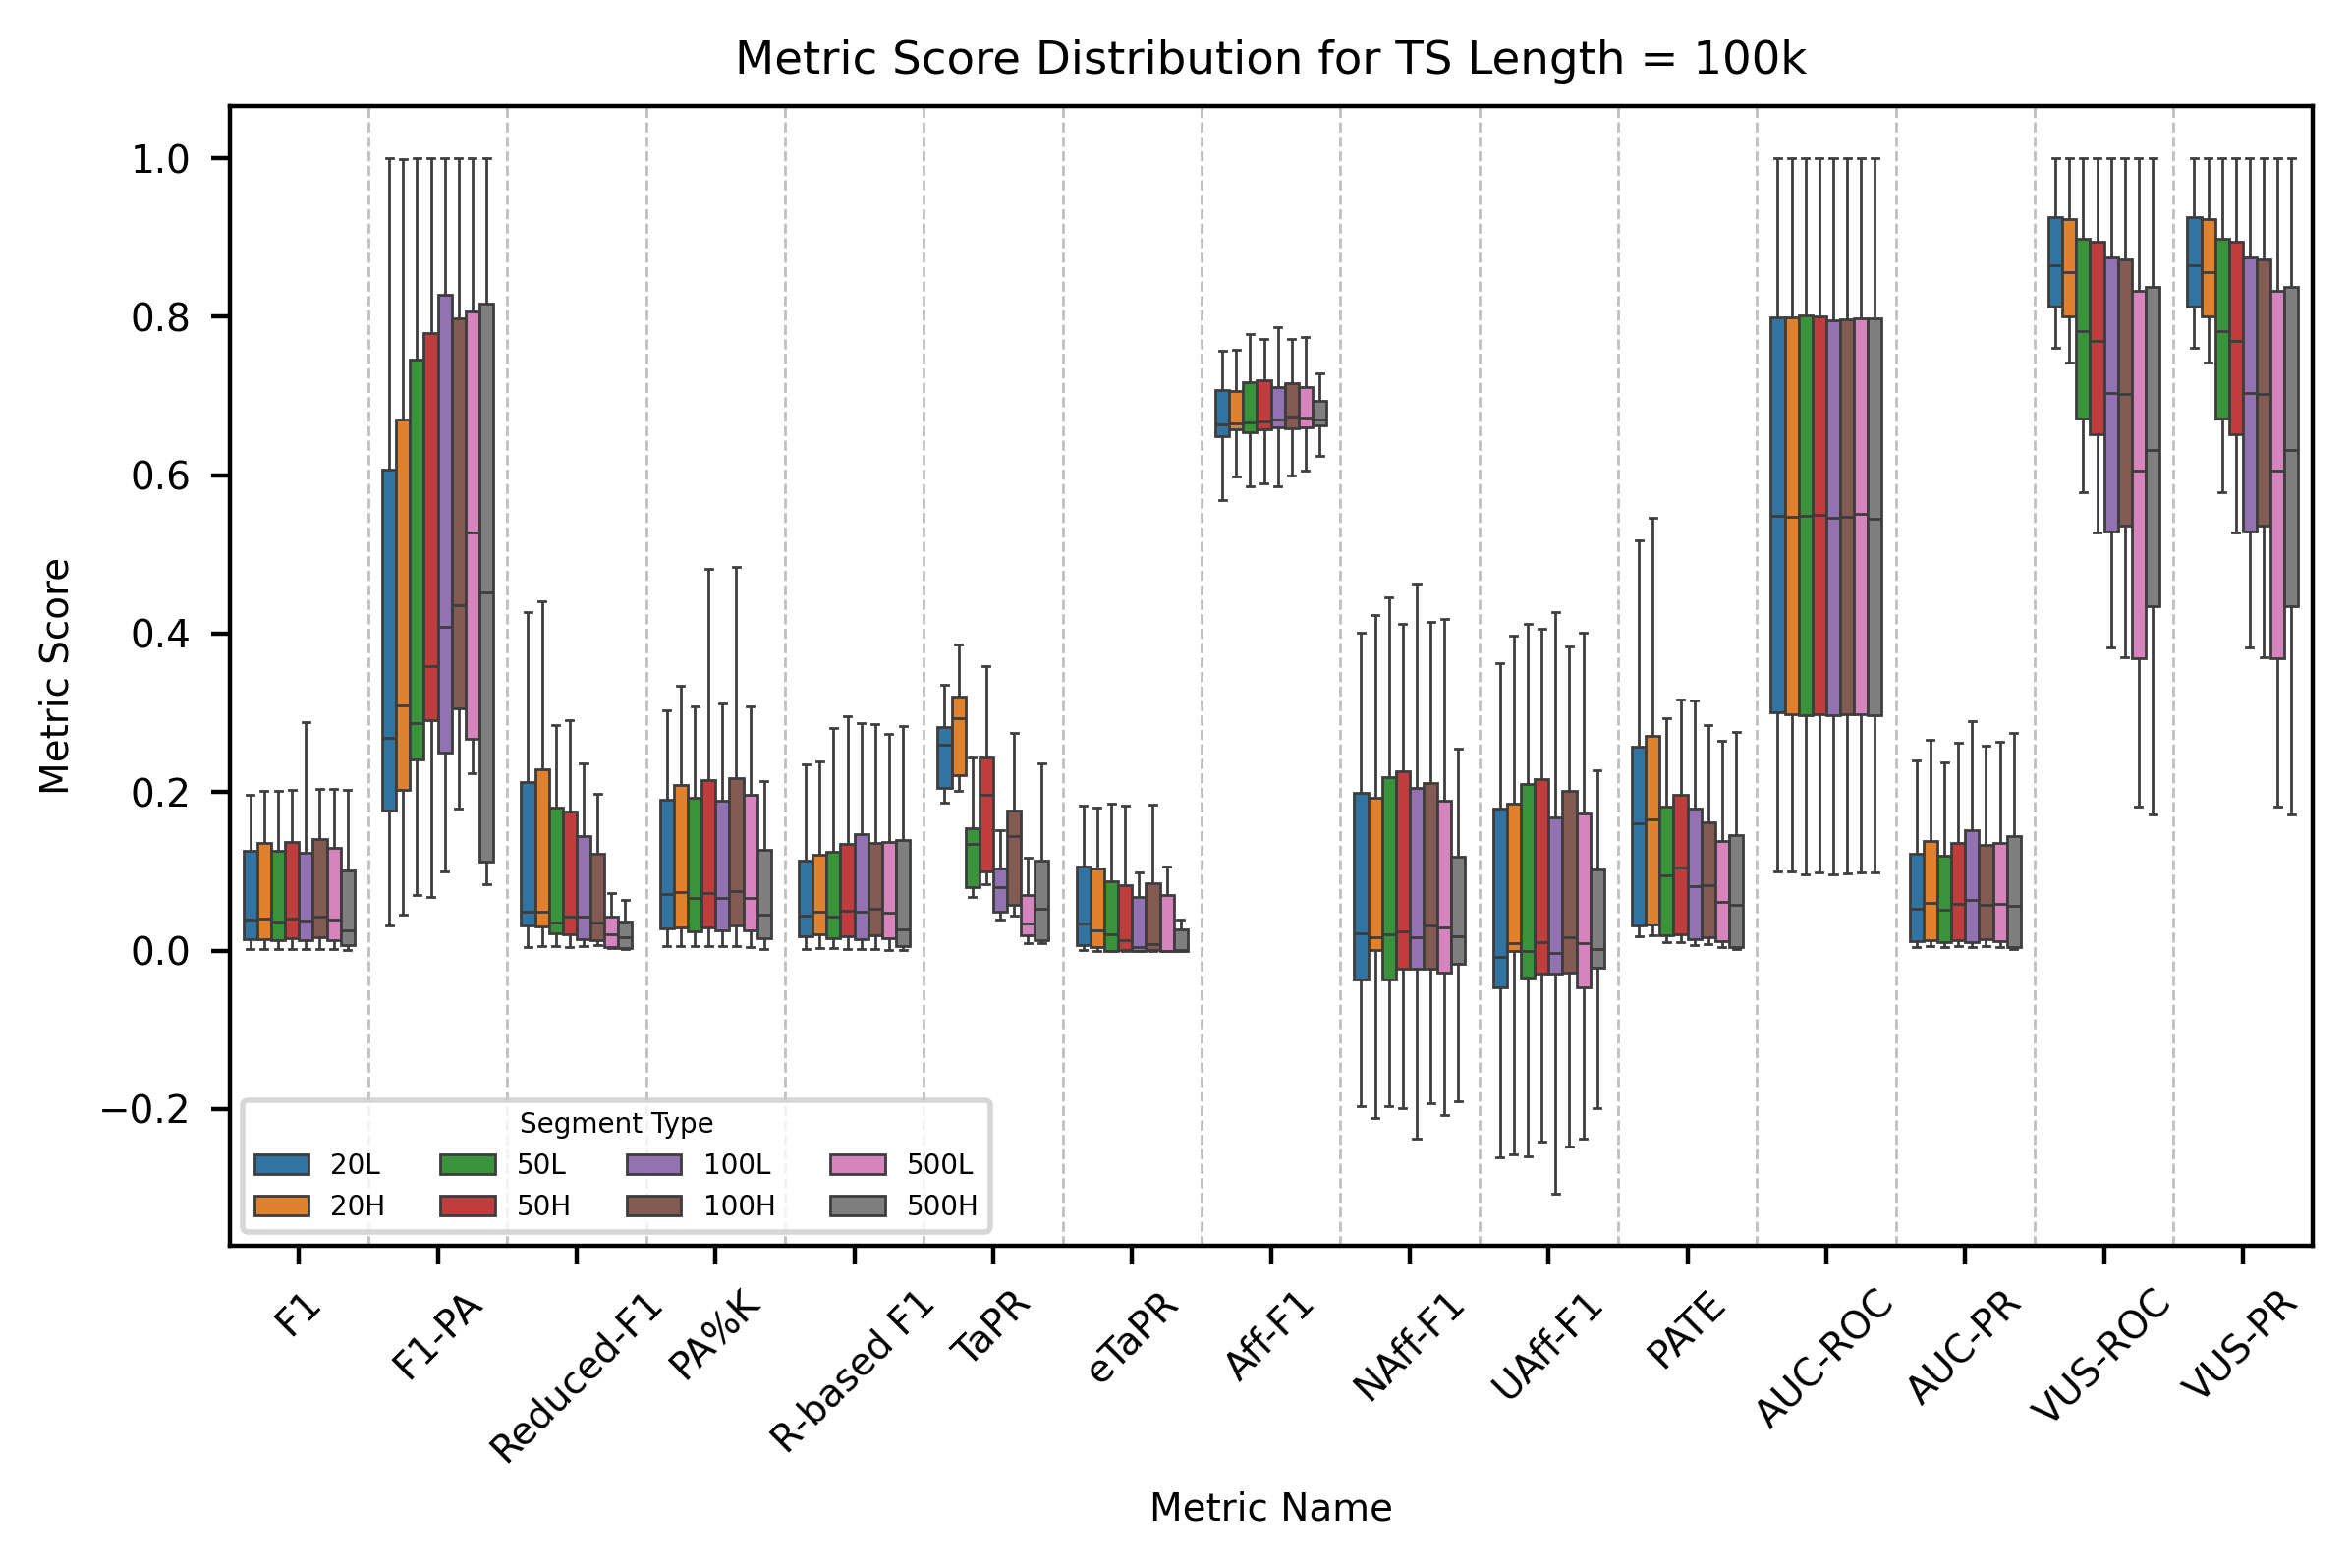

/tmp/ipykernel_3934155/16273882.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  custom_palette = cm.get_cmap('tab10').colors[:len(seg_type_key_list)]


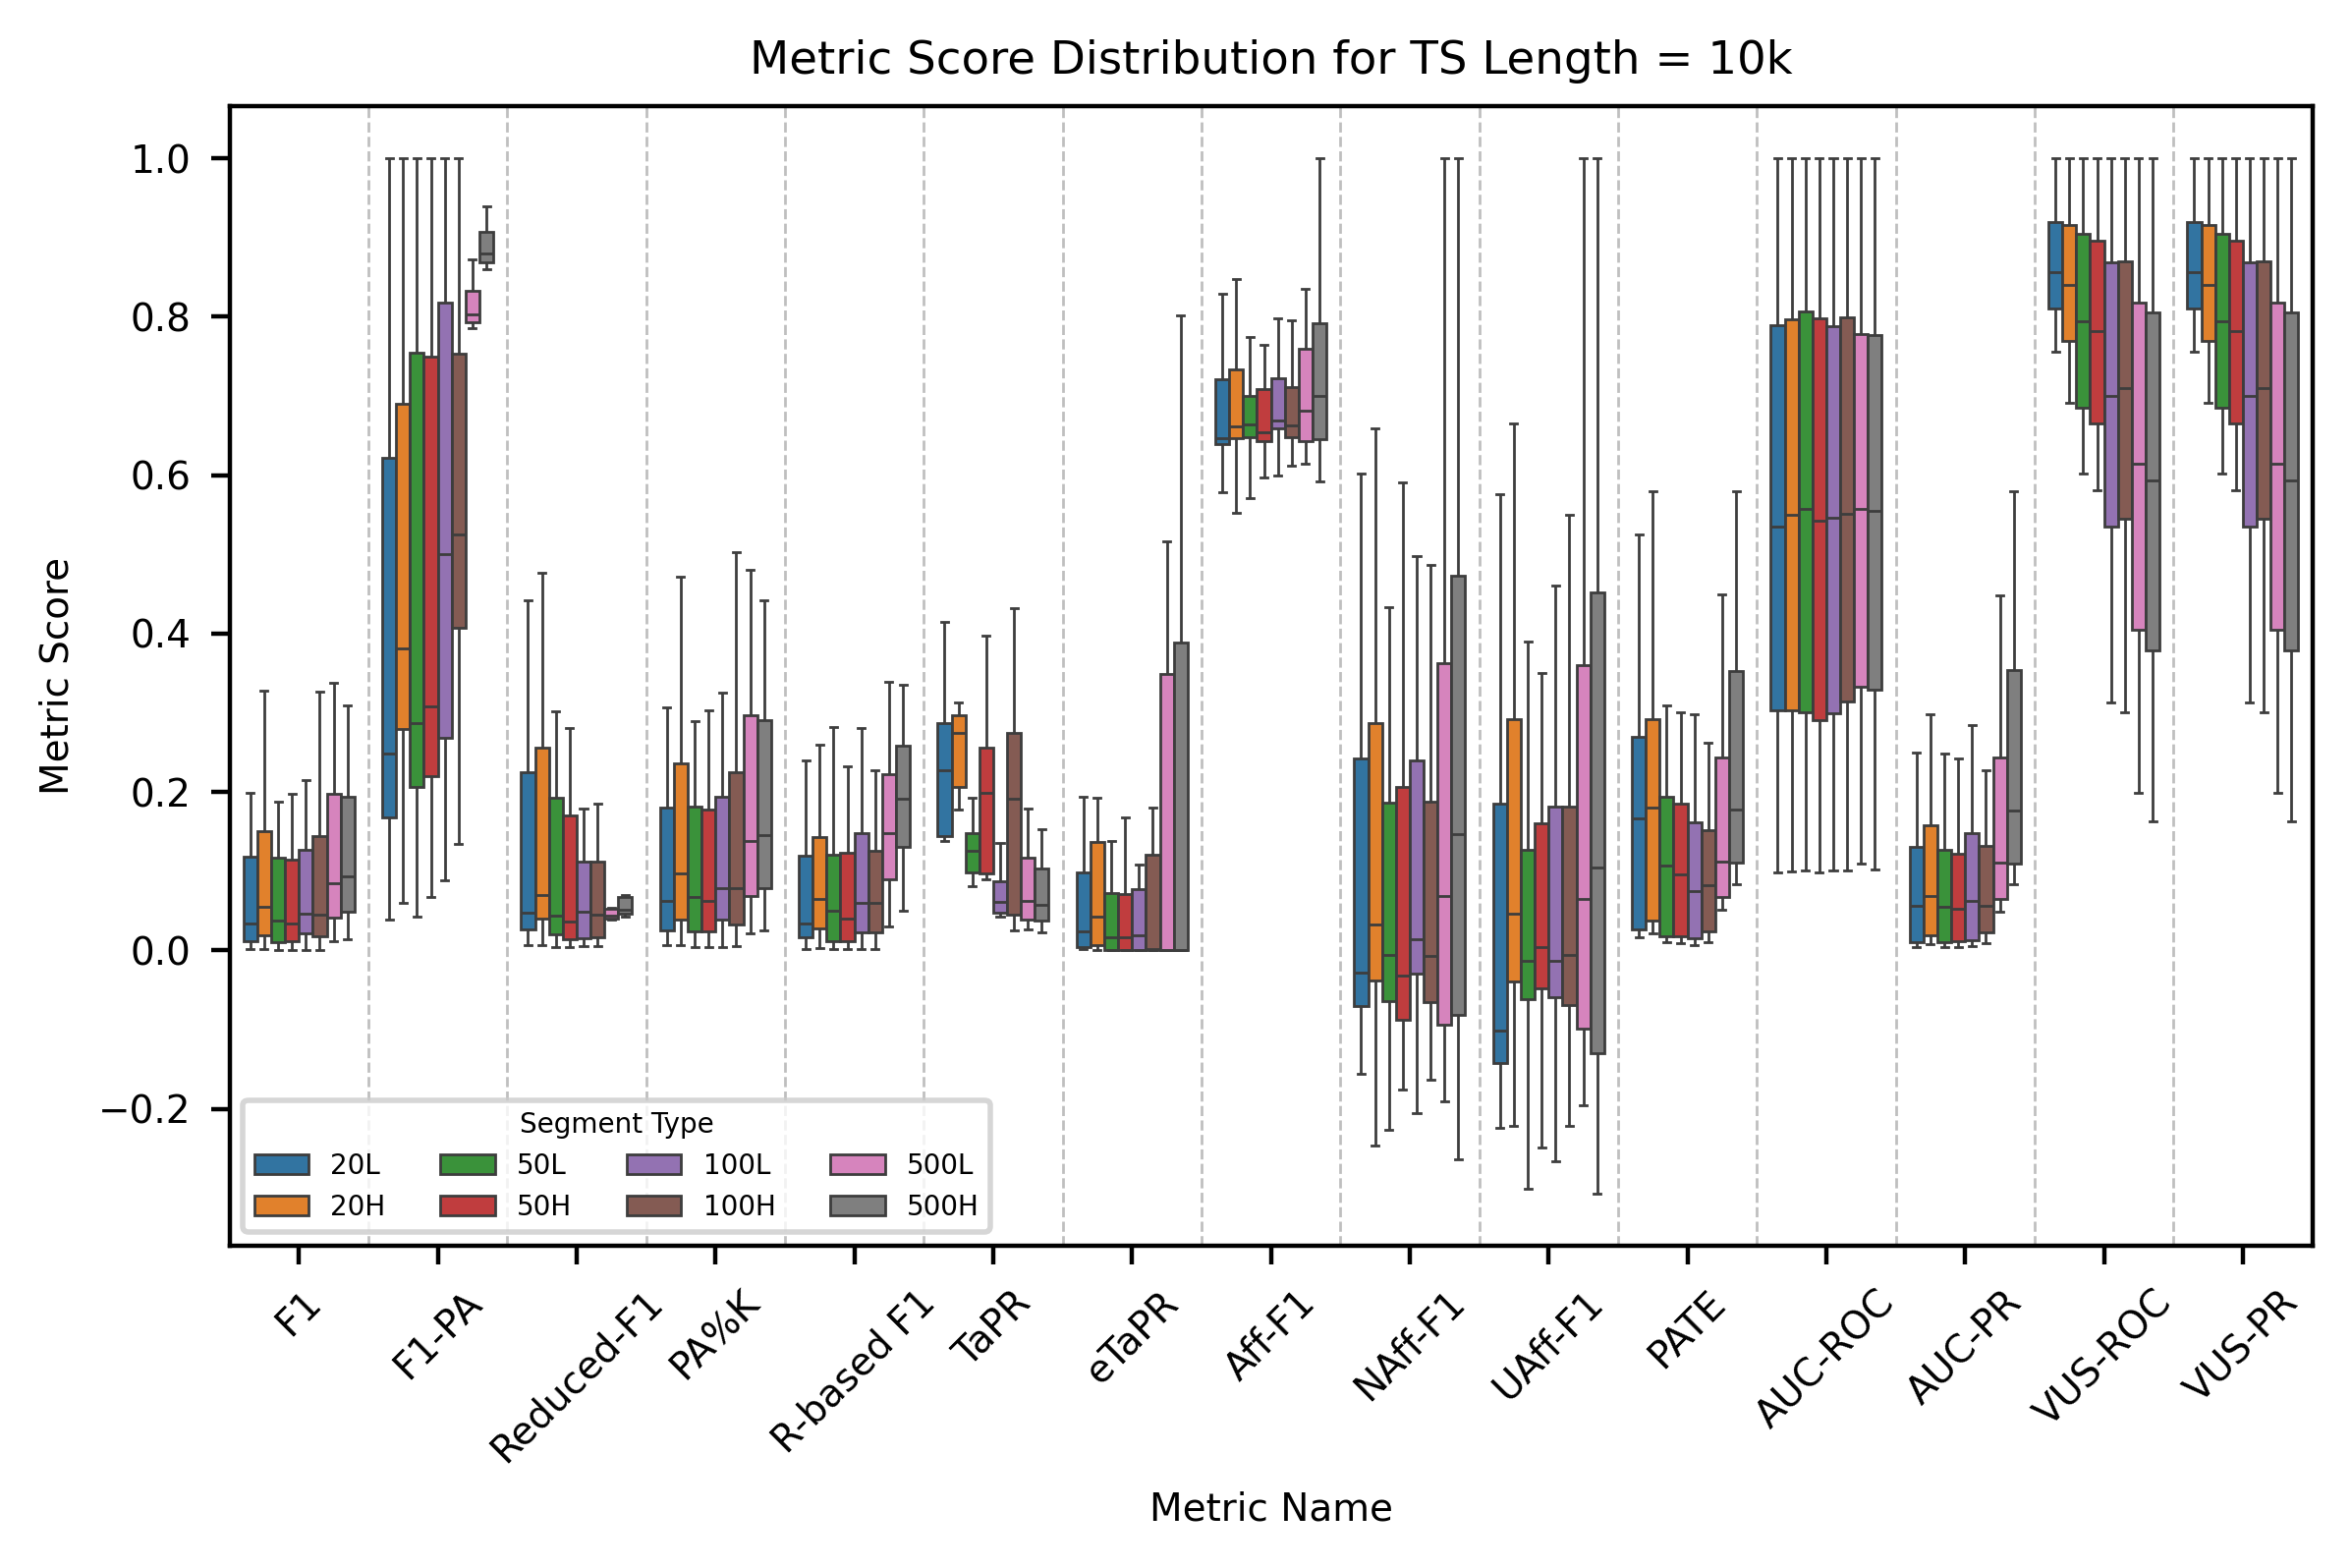

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm

def plot_latency_distribution1(data_new, ts_len=100000):
    df = data_new.copy()

    df = df[df['ts_len'] == ts_len]
    plt.figure(figsize=(6, 4), dpi=400)
    
    plt.rcParams['font.size'] = 7
    custom_palette = cm.get_cmap('tab10').colors[:len(seg_type_key_list)]
    plot1_handle = sns.boxplot(x='metric_name', y='mean_val', data=df, 
                order=metric_sort, 
                hue='seg_type', 
                hue_order=seg_type_key_list,
                showfliers=False,
                # 线粗
                linewidth=0.5,
                palette=custom_palette)
    # 计算每个分组的平均值
    mean_values = df.groupby('metric_name')['mean_val'].mean().reset_index()
    std_values = df.groupby('metric_name')['mean_val'].std().reset_index()
    mean_values = mean_values.sort_values(by='metric_name', key=lambda x: x.apply(sort_metric_key))
    std_values = std_values.sort_values(by='metric_name', key=lambda x: x.apply(sort_metric_key))

    # 在上方显示平均值
    x_positions = np.arange(len(metric_sort))  # 获取 x 轴的位置
    unique_segs = metric_sort
    seg_positions = np.arange(len(unique_segs))

    # 在每个 seg 类别之间添加灰色虚线
    for pos in seg_positions[:-1]:
        plt.axvline(x=pos + 0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
        
    plt.legend(title='Segment Type', 
               loc='lower left', 
            #    bbox_to_anchor=(1, 1), 
               fontsize=5, 
               title_fontsize=5,
               ncol=4)
    tmp = '100k' if ts_len == 100000 else f'{ts_len//1000}k'
    plt.title(f'Metric Score Distribution for TS Length = {tmp}')
    plt.xlabel('Metric Name')
    plt.ylabel('Metric Score')
    # plt.yscale('log', base=10)  # 设置y轴为对数坐标
    plt.xticks(rotation=45)
    out_pth2 = f'/home/zzj/projects/FTSAD/supp_files/seg_len_val_{ts_len}.pdf'
    plt.tight_layout()
    plt.savefig(out_pth2, bbox_inches='tight')
    plt.show()

plot_latency_distribution1(data_new)  # Plot for ts_len = 100000
plot_latency_distribution1(data_new,10000)  # Plot for ts_len = 100000

   metric_name        ratio
0       AUC-PR   599.703249
1      AUC-ROC    10.363631
2       Aff-F1     1.804429
3           F1  1139.142857
4        F1-PA    31.963583
5      NAff-F1    -3.786724
6         PA%K   442.212424
7         PATE   495.087819
8   R-based F1   482.725382
9   Reduced-F1   469.874981
10        TaPR    41.041000
11     UAff-F1    -3.033325
12      VUS-PR     6.152910
13     VUS-ROC     6.152910
14       eTaPR          inf


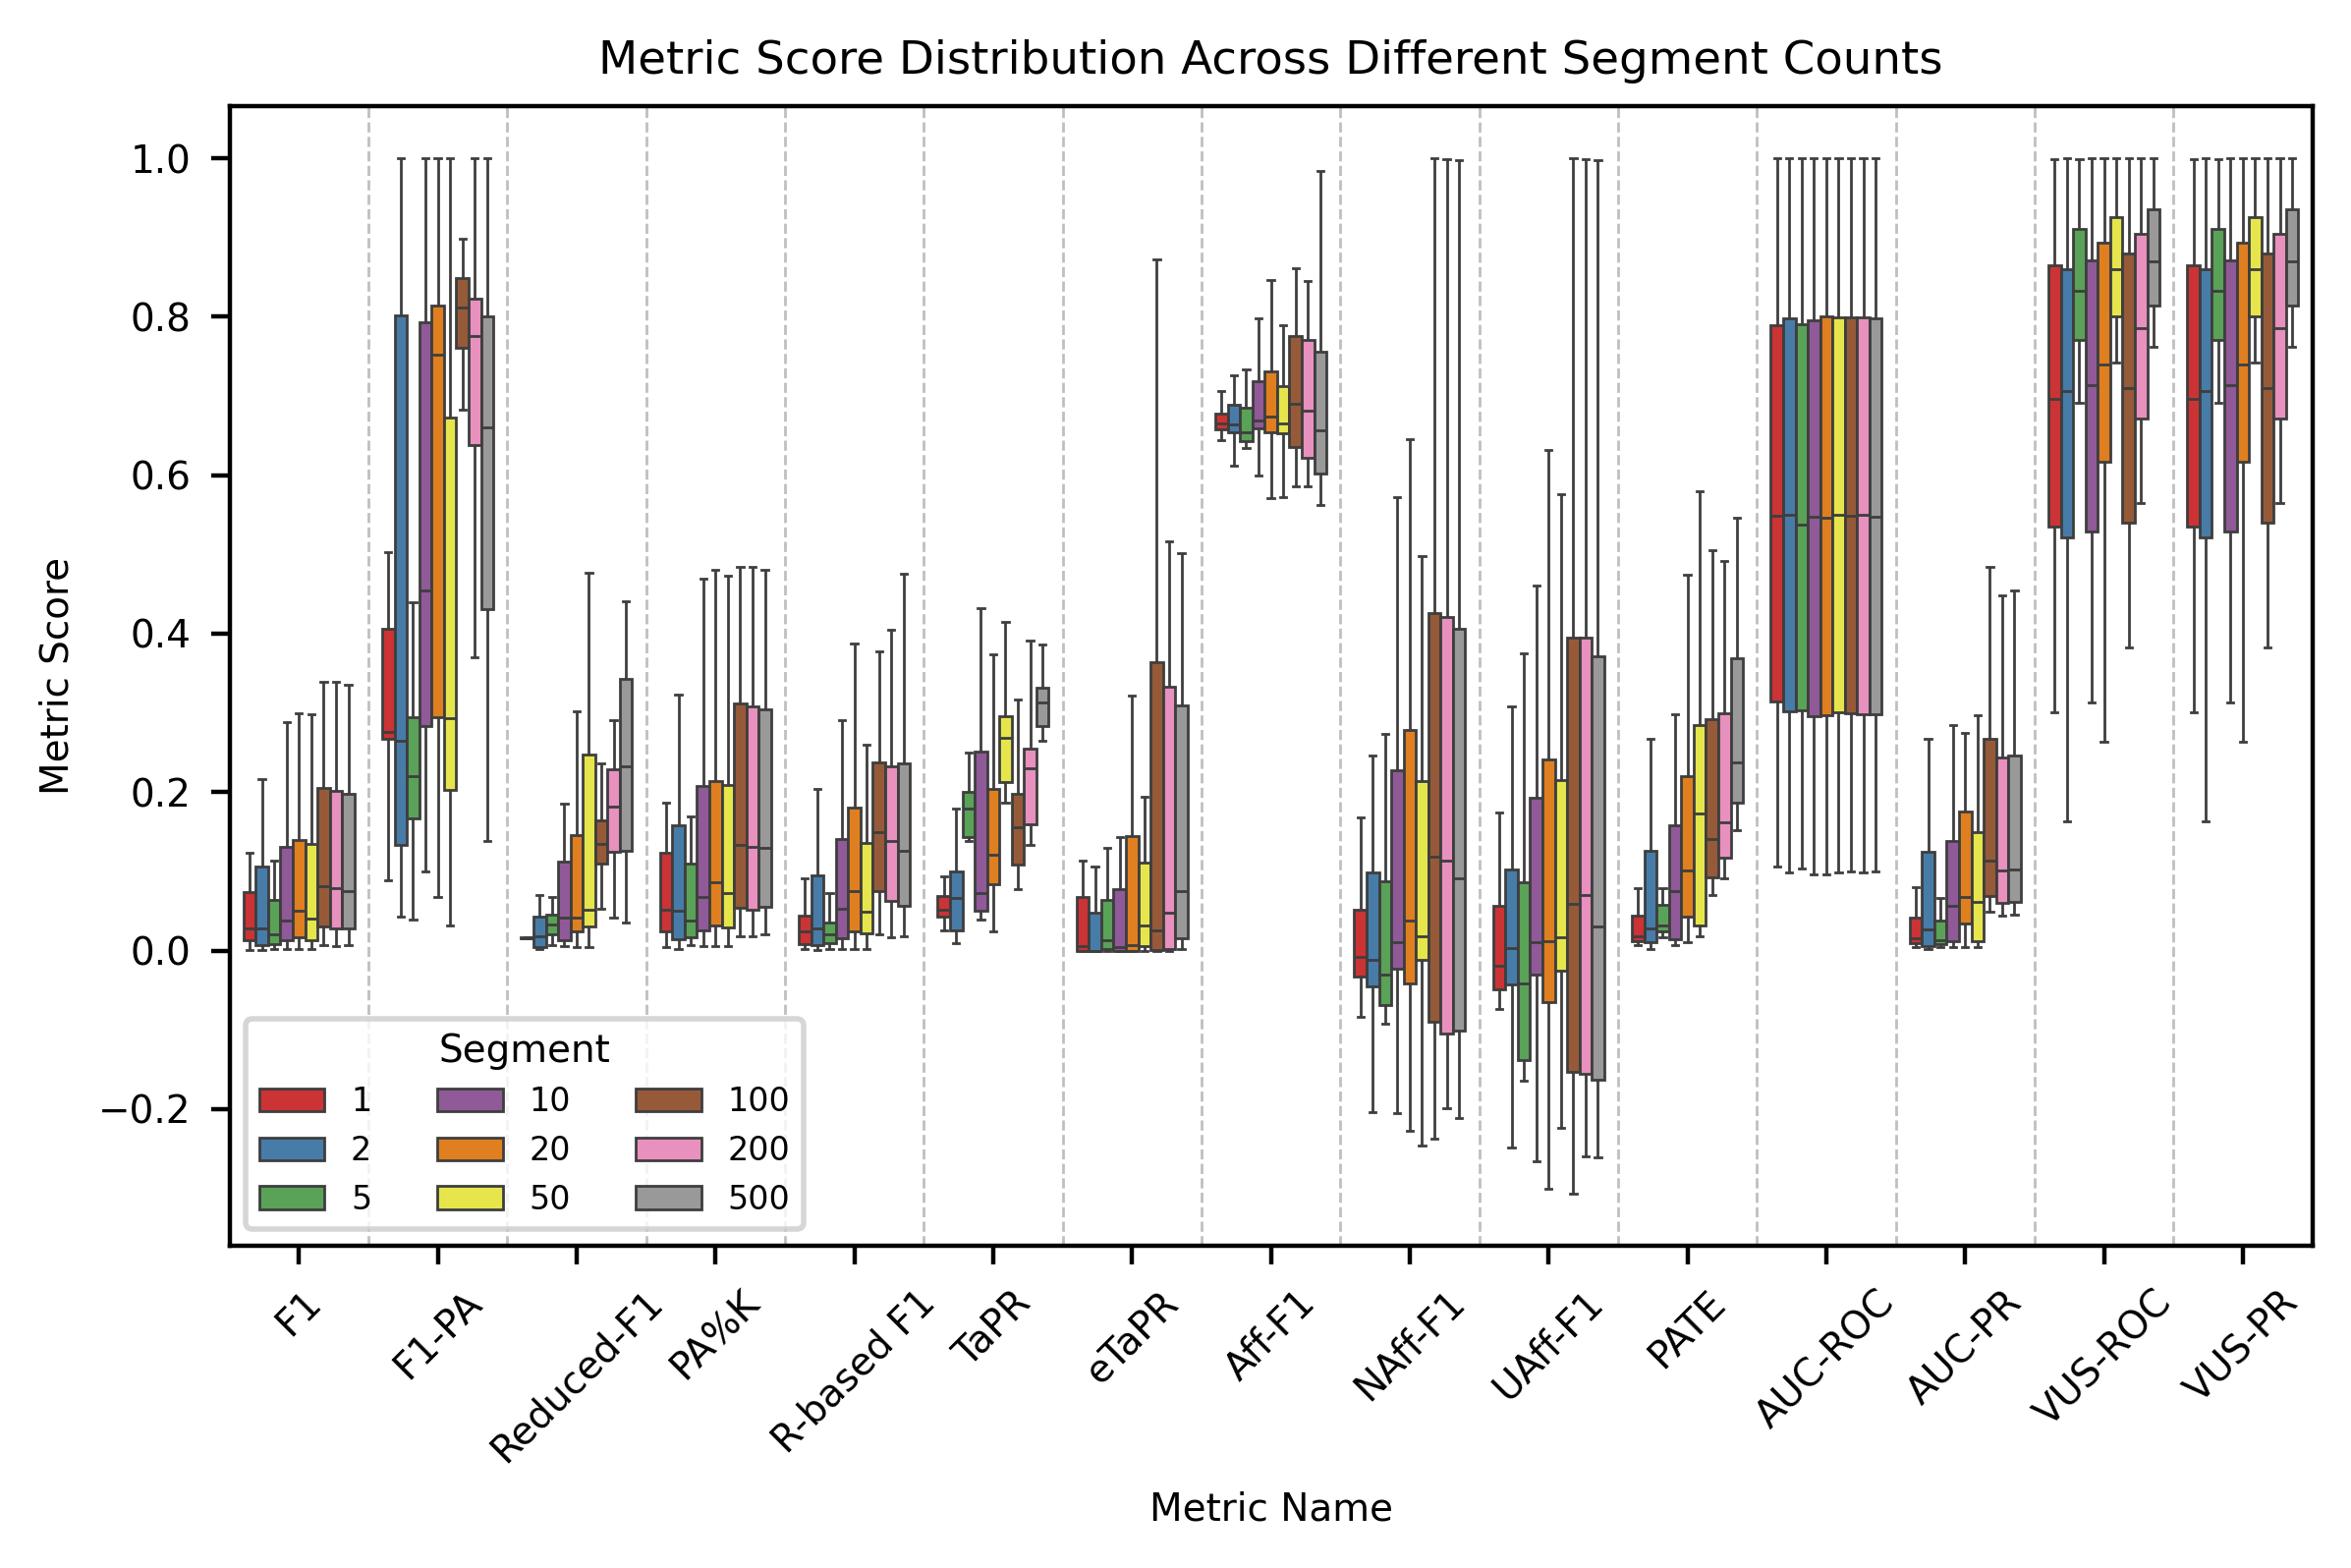

   metric_name       ratio
0       AUC-PR  599.703249
1      AUC-ROC   10.363631
2       Aff-F1    1.772966
3           F1  486.549153
4        F1-PA   14.821729
5      NAff-F1   -4.215562
6         PA%K  154.808522
7         PATE  492.995750
8   R-based F1  187.593564
9   Reduced-F1  230.126691
10        TaPR   14.601622
11     UAff-F1   -3.258324
12      VUS-PR    5.830776
13     VUS-ROC    5.830776
14       eTaPR         inf


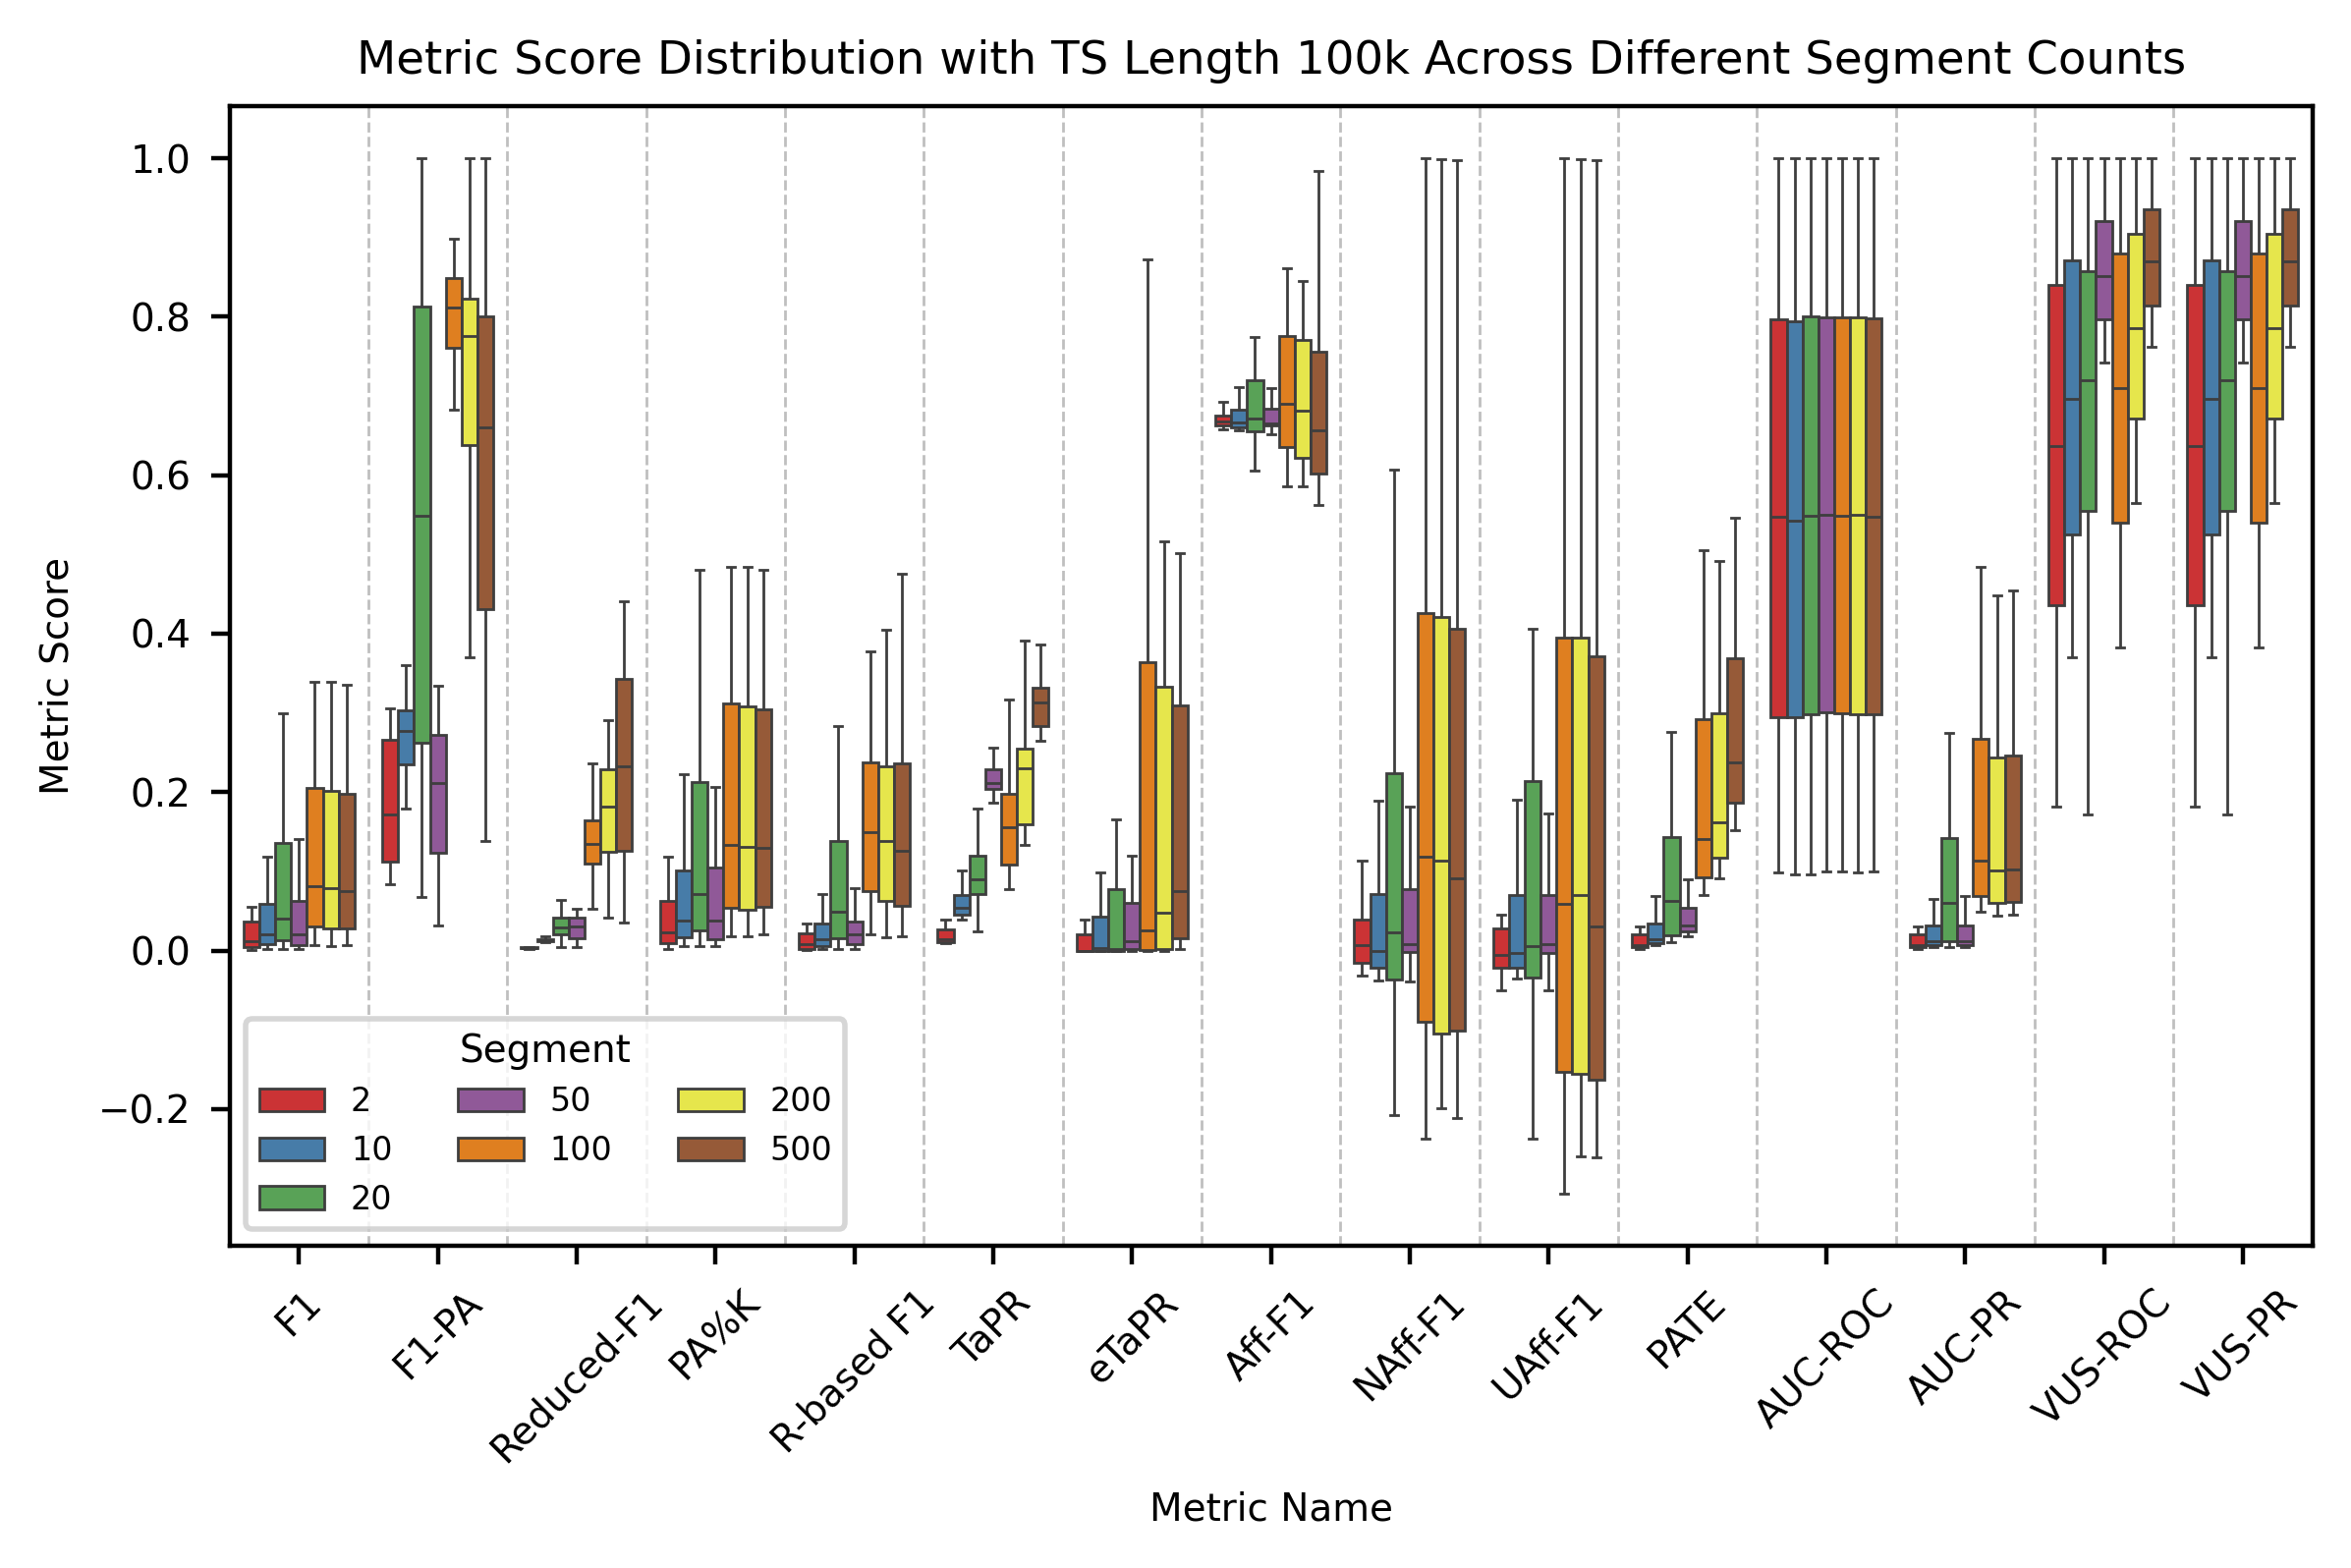

   metric_name       ratio
0       AUC-PR  230.862077
1      AUC-ROC   10.193398
2       Aff-F1    1.804429
3           F1  623.571429
4        F1-PA   23.212500
5      NAff-F1   -3.786724
6         PA%K  204.289429
7         PATE  136.137693
8   R-based F1  246.557881
9   Reduced-F1  254.000000
10        TaPR   16.095302
11     UAff-F1   -3.033325
12      VUS-PR    6.152910
13     VUS-ROC    6.152910
14       eTaPR         inf


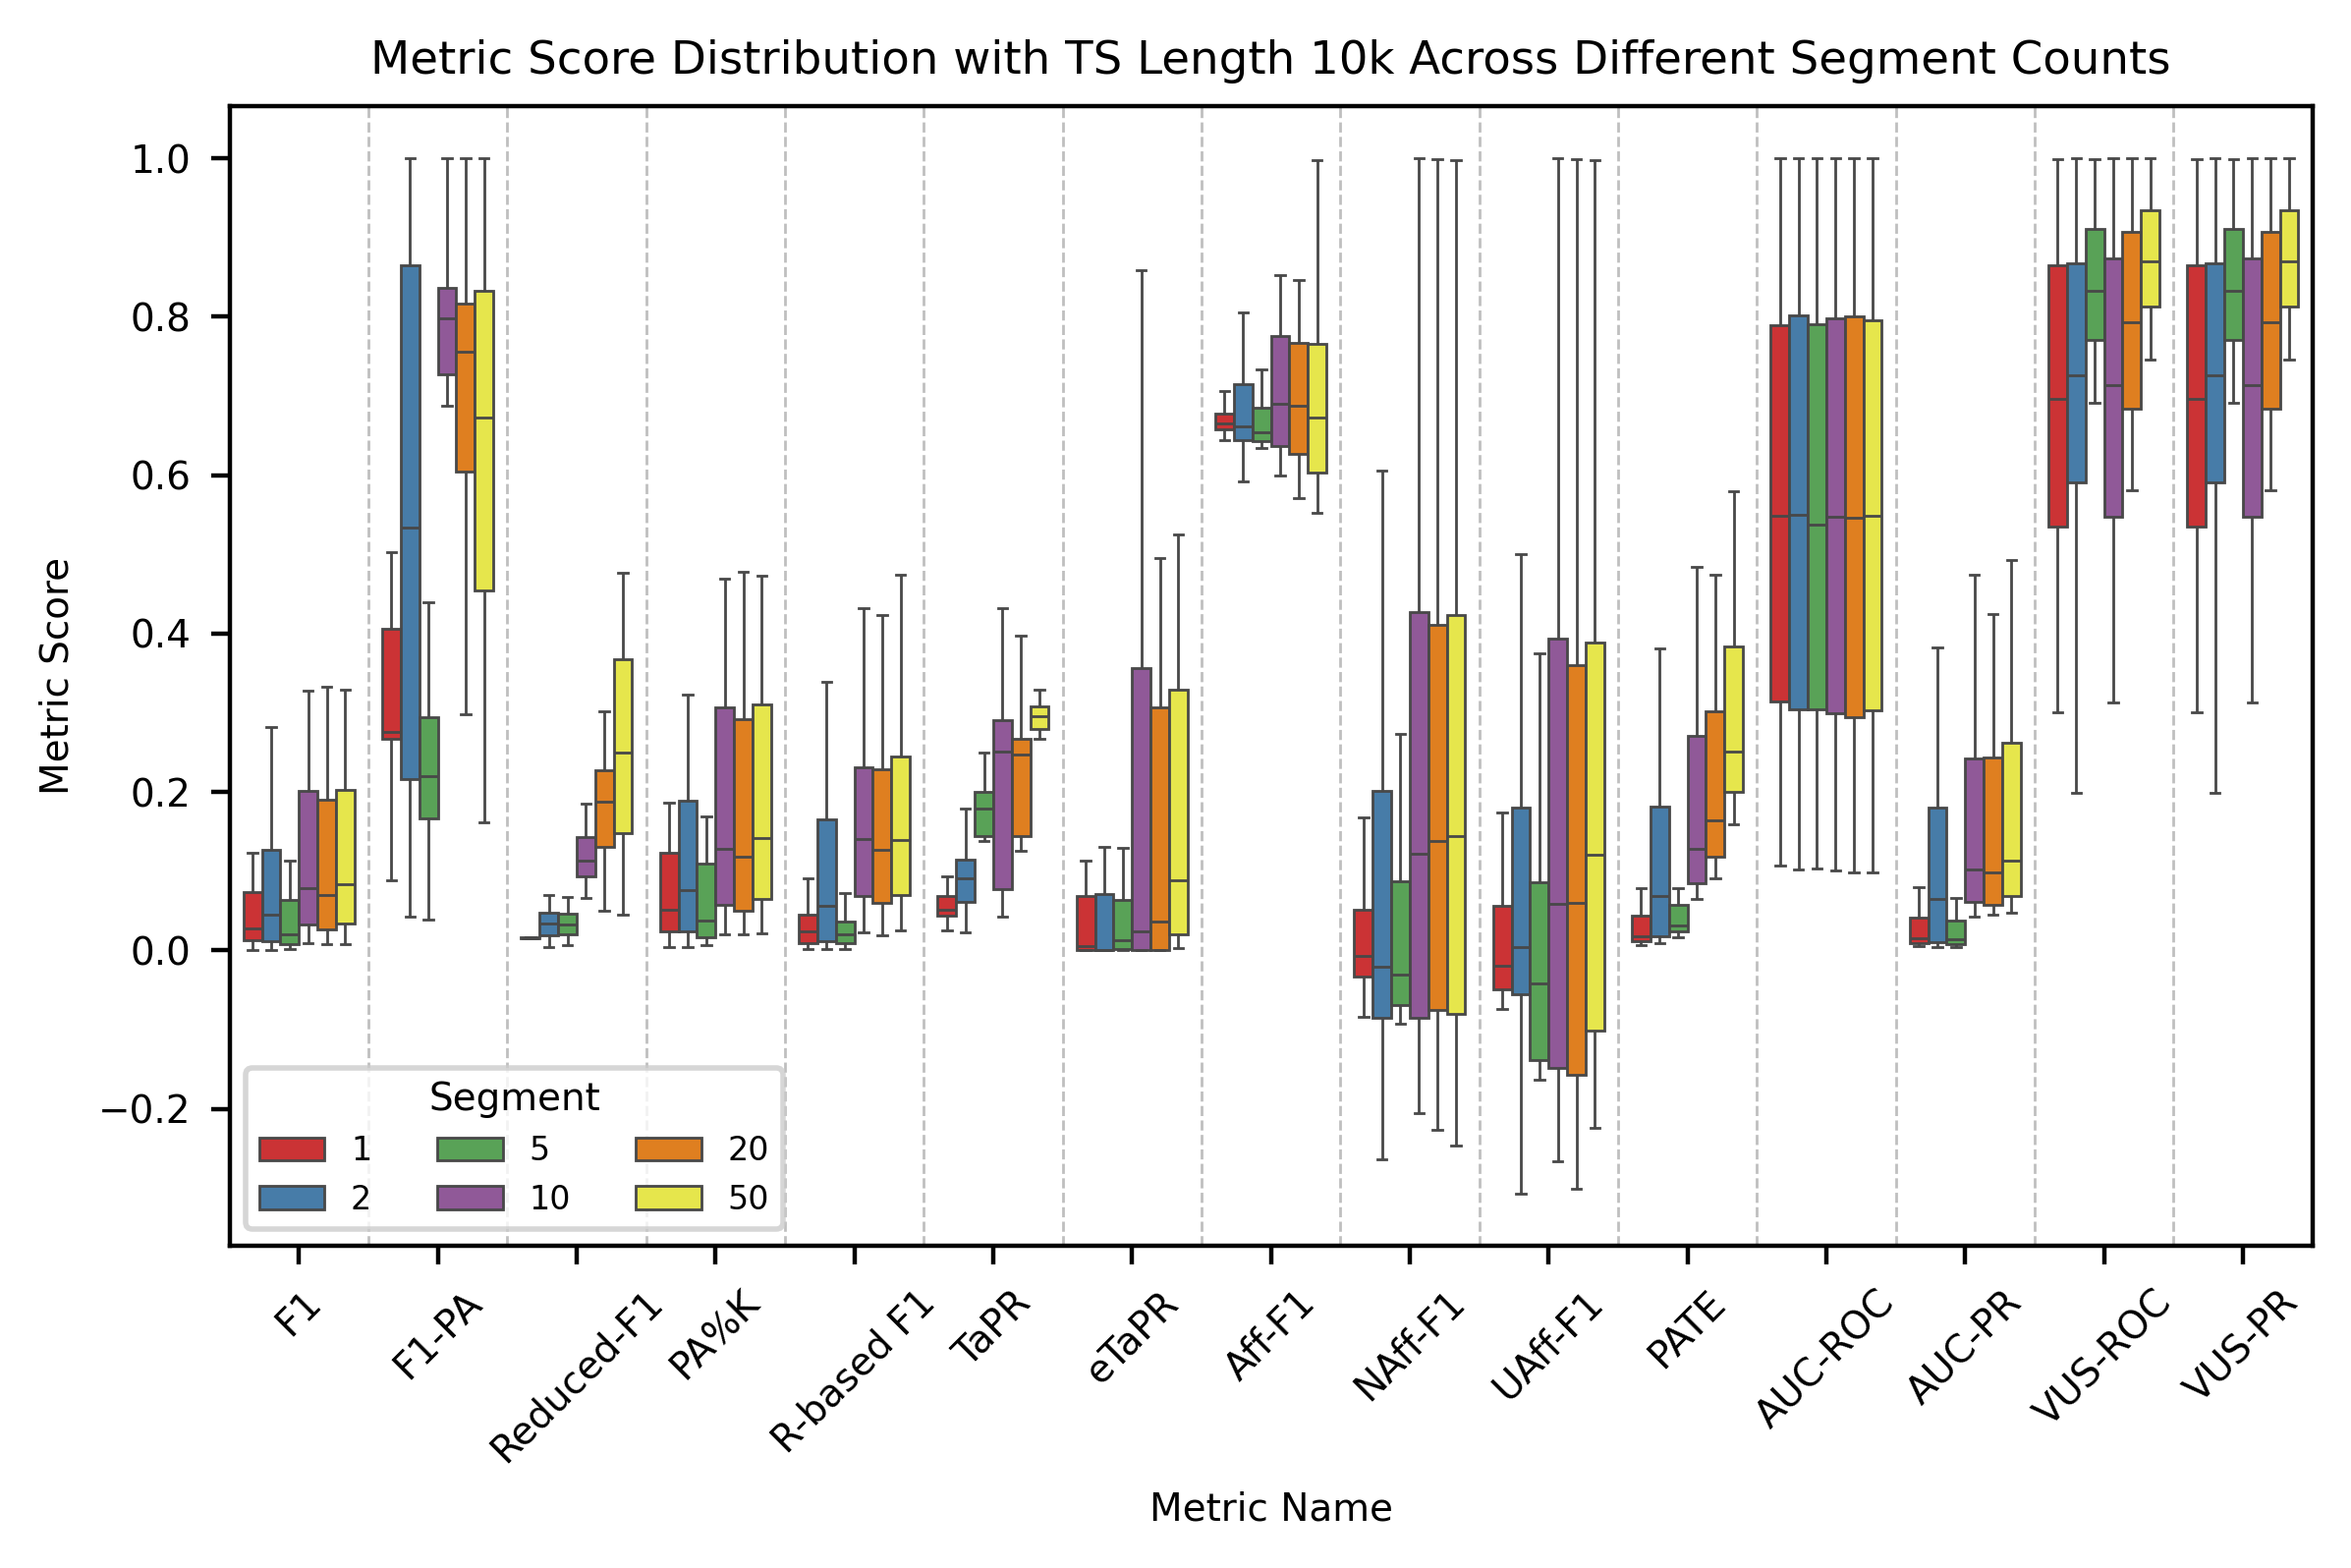

In [9]:
def plot_latency_distribution2(data_new, ts_len=None):
    df = data_new.copy()
    if ts_len is not None:
        df = df[df['ts_len'] == ts_len]

    plt.figure(figsize=(6, 4), dpi=400)
    
    plt.rcParams['font.size'] = 7
    seg_list = df['seg'].unique()
    seg_list = sorted(seg_list, key=lambda x: int(x))  # Sort segments numerically
    plot1_handle = sns.boxplot(x='metric_name', y='mean_val', data=df, 
                order=metric_sort, 
                hue='seg', 
                hue_order=seg_list,
                showfliers=False,
                linewidth=0.5,
                palette='Set1')  # BEGIN: Changed color palette
                # palette='Set2'  # END: Changed color palette
    min_max_ratios = df.groupby(['metric_name', 'seg'])['mean_val'].agg(['min', 'max']).reset_index()
    min_max_ratios['ratio'] = min_max_ratios['max'] / min_max_ratios['min']
    seg_list = df['seg'].unique()
    seg_list = sorted(seg_list, key=lambda x: int(x))  # Sort 

    min_max_ratios_max = min_max_ratios.groupby('metric_name')['ratio'].max().reset_index()
    print(min_max_ratios_max)
    # for i, metric in enumerate(metric_sort):
    #     plt.annotate(
    #         f'Max Ratio: {min_max_ratios_max[min_max_ratios_max["metric_name"] == metric]["ratio"].values[0]:.2f}',
    #         xy=(i, 1.05),  # Adjust the y-coordinate for better visibility
    #         ha='center', va='bottom', fontsize=6, color='black'
    #     )
    unique_segs = metric_sort
    seg_positions = np.arange(len(unique_segs))

    # 在每个 seg 类别之间添加灰色虚线
    for pos in seg_positions[:-1]:
        plt.axvline(x=pos + 0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)    
    plt.legend(title='Segment',
               loc='lower left', 
               fontsize=6, 
               title_fontsize=7,
               ncol=3)
    if ts_len is not None:
        tmp = '100k' if ts_len == 100000 else f'{ts_len//1000}k'
        plt.title(f'Metric Score Distribution with TS Length {tmp} Across Different Segment Counts')
        tmp_name = f'_{tmp}'
    else:
        tmp_name = ''
        plt.title('Metric Score Distribution Across Different Segment Counts')
    plt.xlabel('Metric Name')
    plt.ylabel('Metric Score')
    # plt.yscale('log', base=10)  # 设置y轴为对数坐标
    plt.xticks(rotation=45)
    out_pth2 = f'/home/zzj/projects/FTSAD/supp_files/seg_val{tmp_name}.pdf'
    plt.tight_layout()
    plt.savefig(out_pth2, bbox_inches='tight')
    plt.show()

plot_latency_distribution2(data_new)  # Plot for all segments
plot_latency_distribution2(data_new,100000)  # Plot for all segments
plot_latency_distribution2(data_new,10000)  # Plot for all segments


[100000  10000]


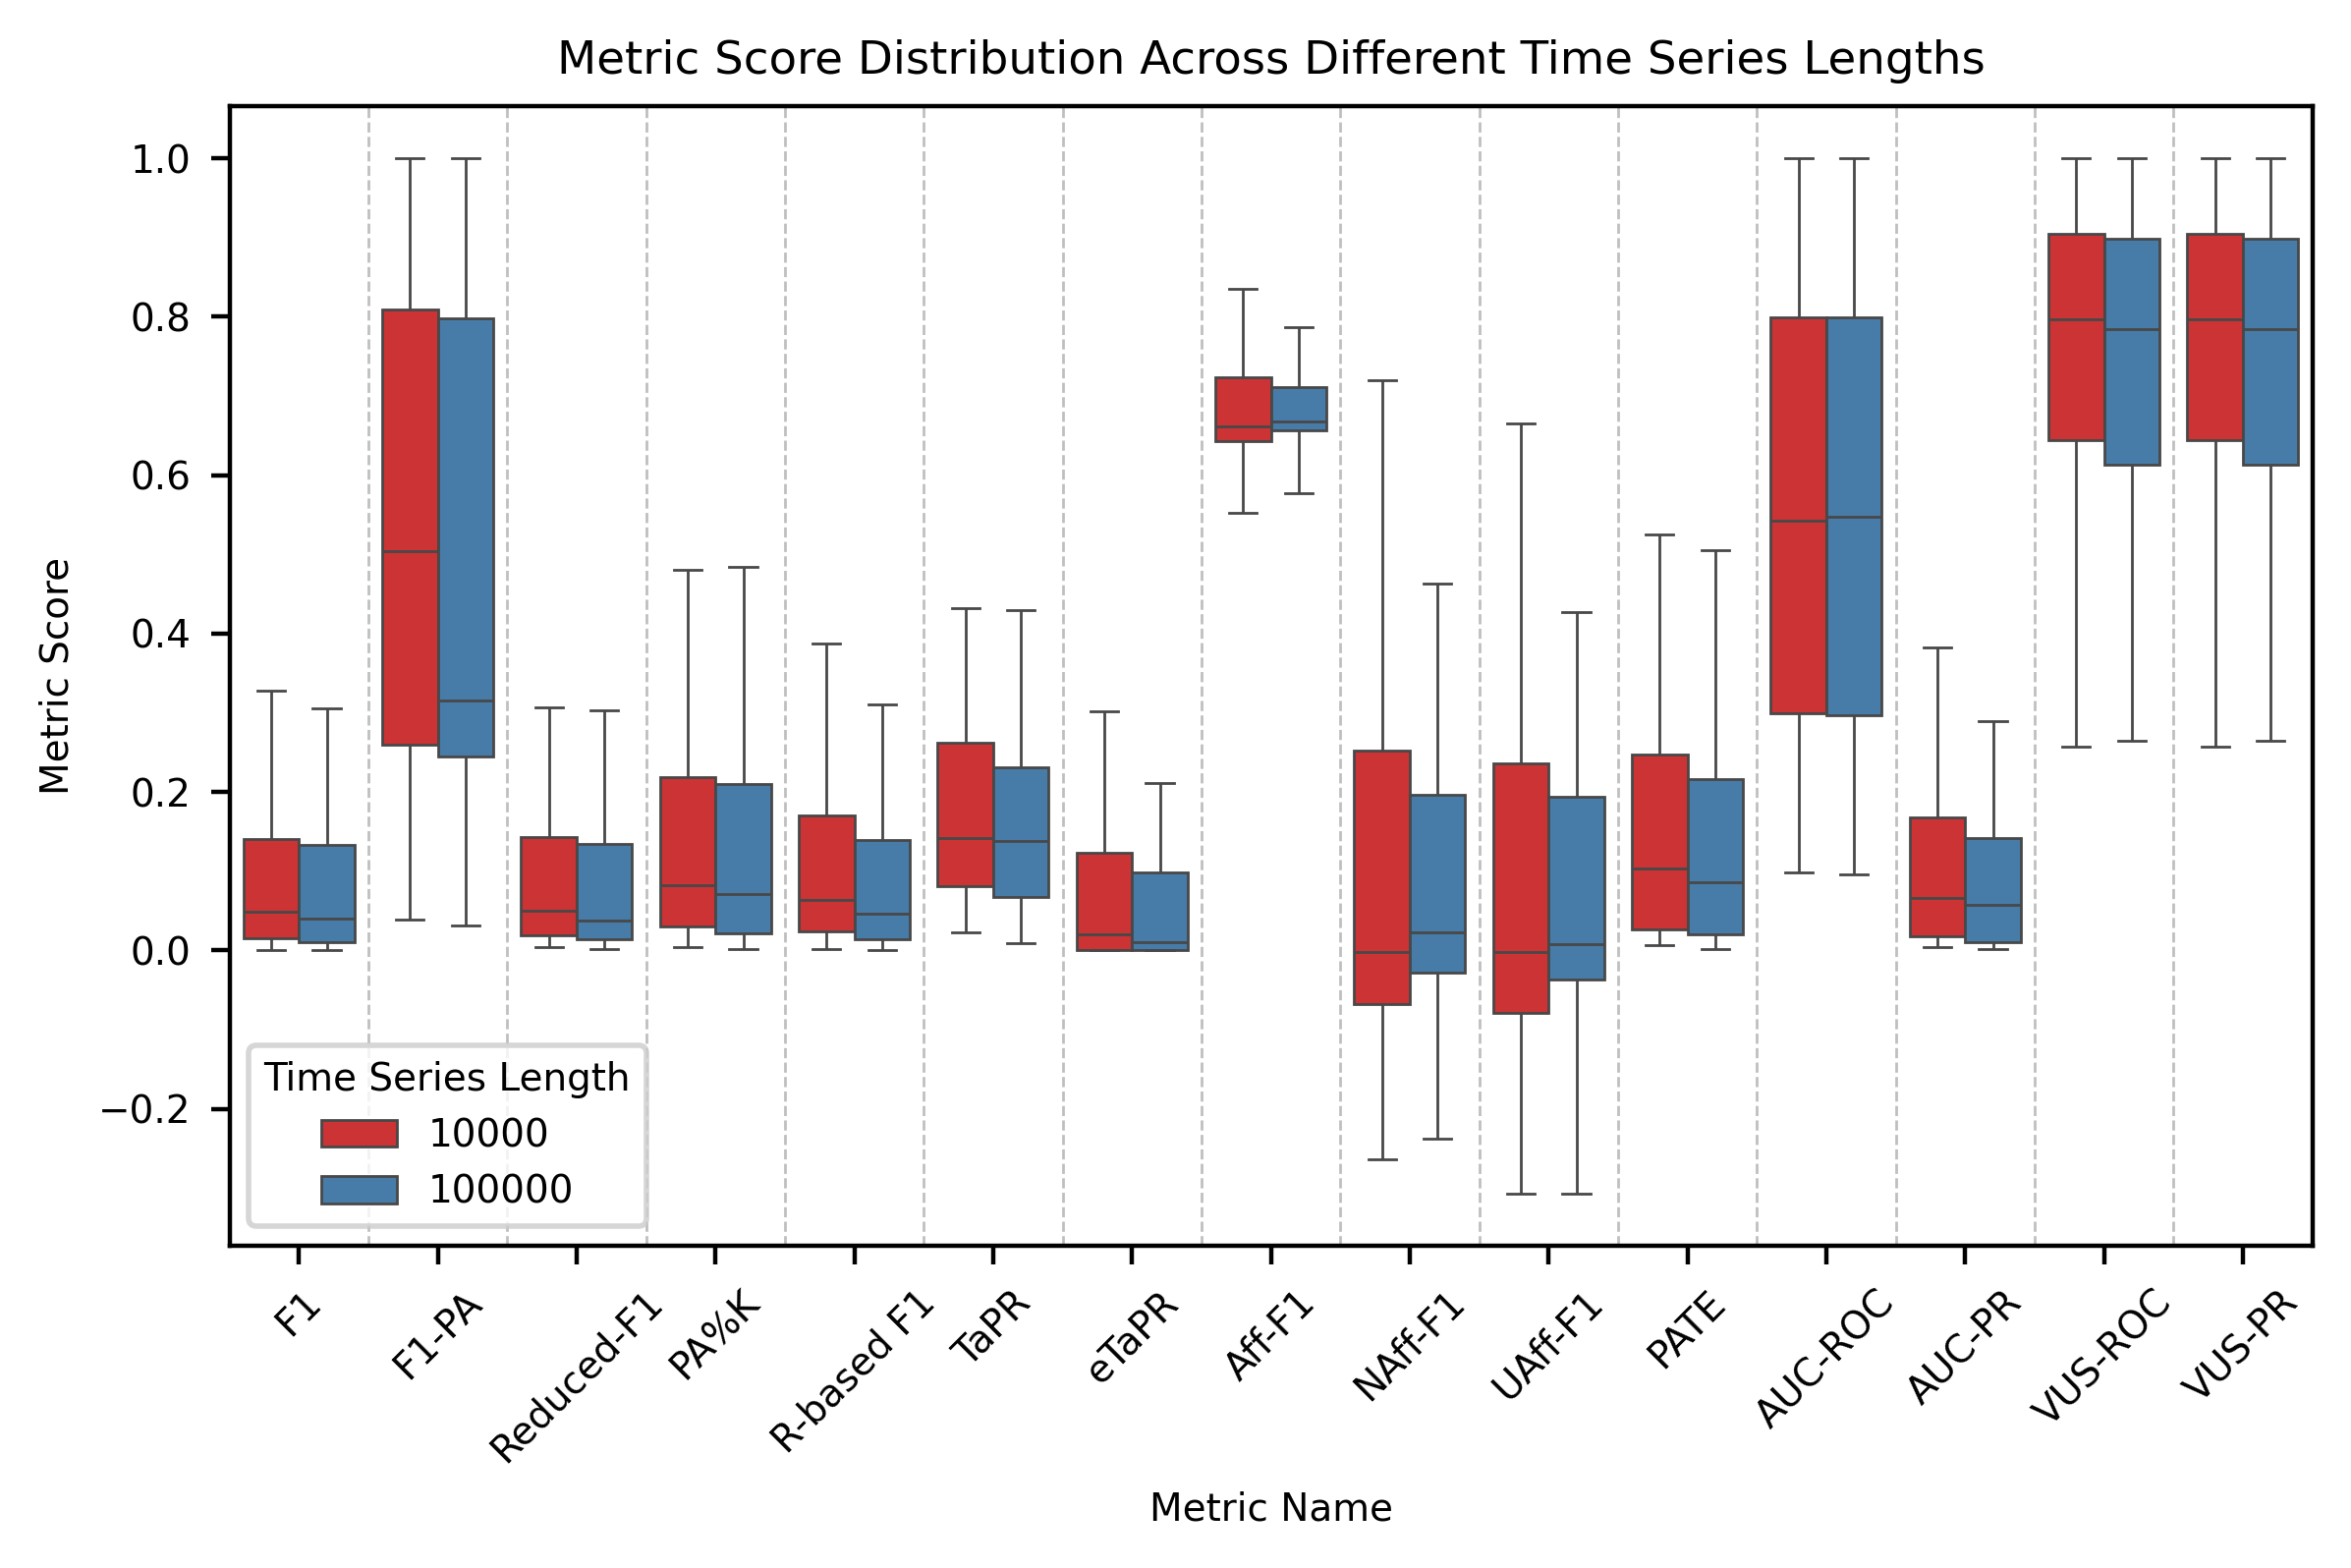

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm

def plot_latency_distribution_ts_len(data_new):
    df = data_new.copy()


    plt.figure(figsize=(6, 4), dpi=400)
    
    plt.rcParams['font.size'] = 7
    seg_list = df['ts_len'].unique()
    # delete nan
    # seg_list = [s for s in seg_list if pd.notna(s)]
    print(seg_list)
    seg_list = sorted(seg_list)
    plot1_handle = sns.boxplot(x='metric_name', y='mean_val', data=df, 
                order=metric_sort, 
                hue='ts_len', 
                hue_order=seg_list,
                showfliers=False,
                linewidth=0.5,
                palette='Set1')  # BEGIN: Changed color palette
    unique_segs = metric_sort
    seg_positions = np.arange(len(unique_segs))

    # 在每个 seg 类别之间添加灰色虚线
    for pos in seg_positions[:-1]:
        plt.axvline(x=pos + 0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.legend(title='Time Series Length')
    
    plt.title(f'Metric Score Distribution Across Different Time Series Lengths')
        
    plt.xlabel('Metric Name')
    plt.ylabel('Metric Score')
    plt.xticks(rotation=45)
    
    out_pth2 = f'/home/zzj/projects/FTSAD/supp_files/ts_len_val.pdf'
    plt.tight_layout()
    plt.savefig(out_pth2, bbox_inches='tight')
    plt.show()

plot_latency_distribution_ts_len(data_new)  # Plot for all segments

/tmp/ipykernel_3934155/3103160854.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  custom_palette = cm.get_cmap('tab20').colors[:len(model_list)]


    metric_name model_name      mean       std
31           F1   Model100  0.497351  0.217766
32           F1    Model20  0.010170  0.006709
33           F1    Model30  0.017182  0.011638
34           F1    Model40  0.026628  0.017721
35           F1    Model50  0.039545  0.026098
..          ...        ...       ...       ...
122      VUS-PR    Model20  0.536909  0.186562
123      VUS-PR    Model30  0.593095  0.160308
124      VUS-PR    Model40  0.650920  0.133488
125      VUS-PR    Model50  0.709673  0.106750
126      VUS-PR    Model60  0.767837  0.081652

[150 rows x 4 columns]


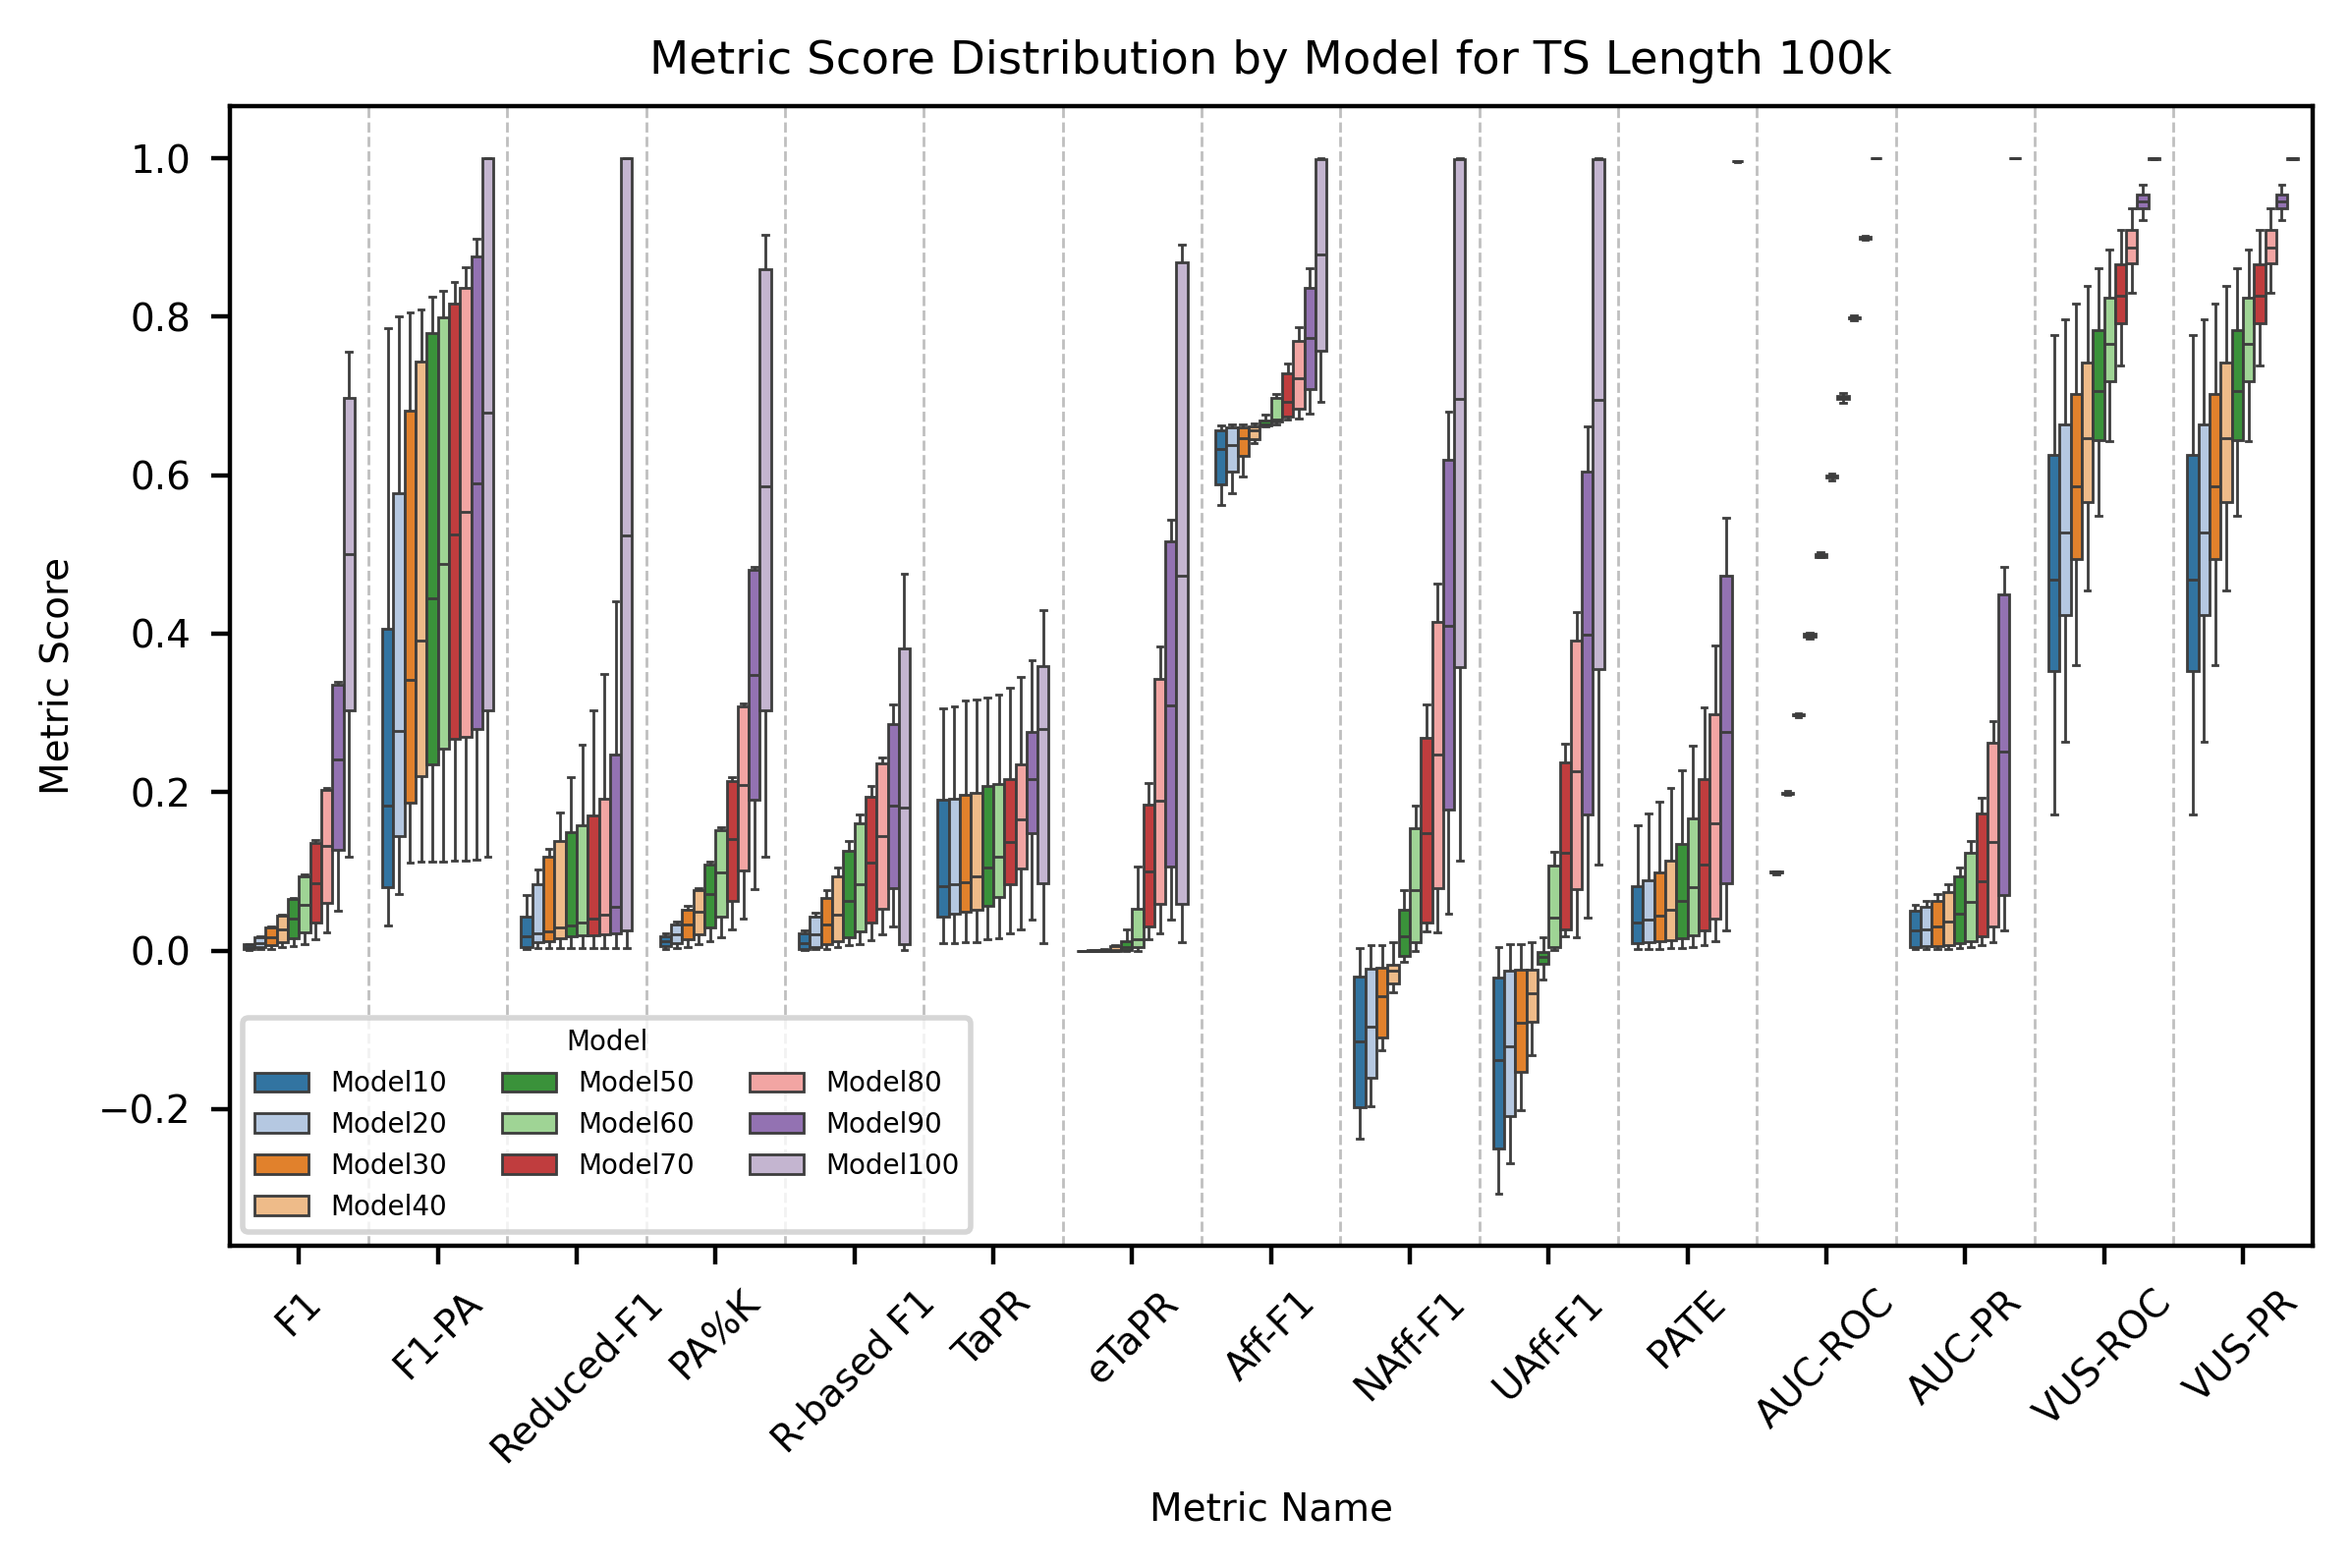

/tmp/ipykernel_3934155/3103160854.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  custom_palette = cm.get_cmap('tab20').colors[:len(model_list)]


    metric_name model_name      mean       std
31           F1   Model100  0.542242  0.195189
32           F1    Model20  0.013170  0.009120
33           F1    Model30  0.021577  0.014040
34           F1    Model40  0.031796  0.019583
35           F1    Model50  0.045993  0.026552
..          ...        ...       ...       ...
122      VUS-PR    Model20  0.567238  0.179334
123      VUS-PR    Model30  0.619059  0.152843
124      VUS-PR    Model40  0.671066  0.127353
125      VUS-PR    Model50  0.726142  0.101485
126      VUS-PR    Model60  0.781079  0.075788

[150 rows x 4 columns]


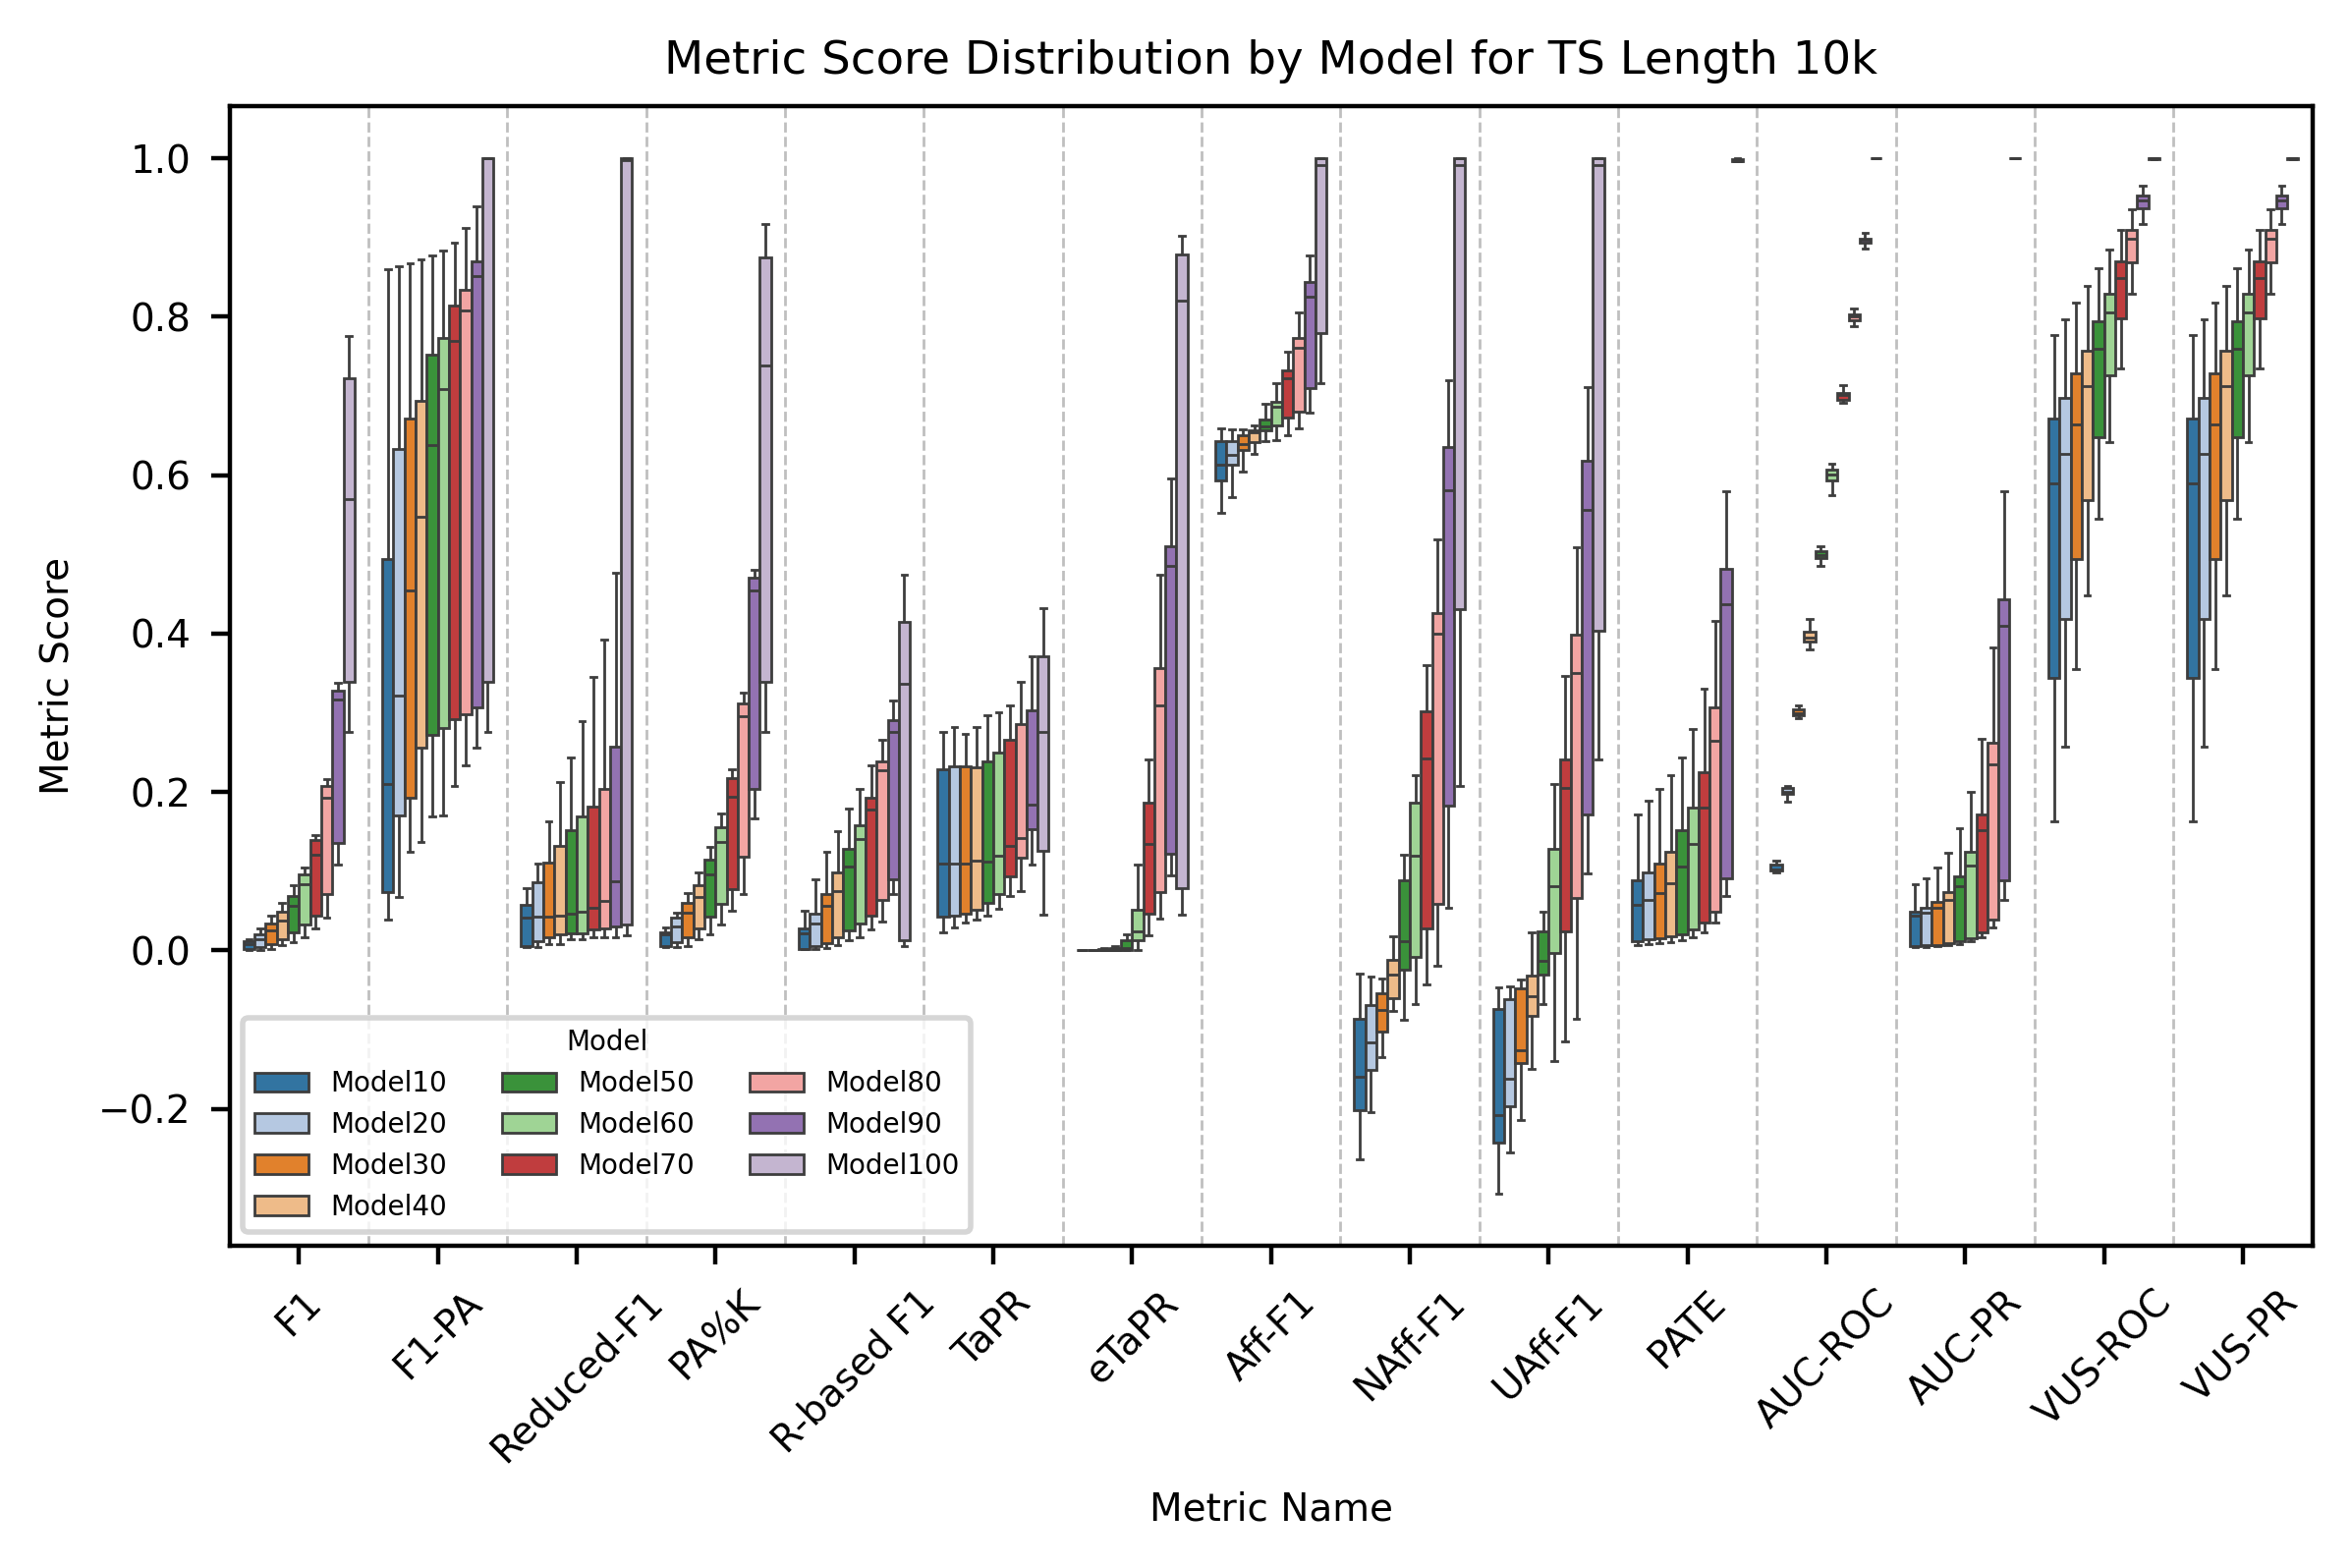

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm


def plot_latency_distribution3(data_new, ts_len=100000):
    df = data_new.copy()

    df = df[df['ts_len'] == ts_len]
    plt.figure(figsize=(6, 4), dpi=400)
    
    plt.rcParams['font.size'] = 7
    model_list = df['model_name'].unique()
    def sort_model_key_mdl(tmp):
        # 提取数字部分
        if tmp.startswith('Model'):
            num_part = tmp.split('Model')[-1]
            return int(num_part)
        else:
            return -float('inf')
        
    model_list = sorted(model_list, key=sort_model_key_mdl)
    # 定义一个包含足够多颜色的列表
    custom_palette = cm.get_cmap('tab20').colors[:len(model_list)]
    plot1_handle = sns.boxplot(x='metric_name', y='mean_val', data=df, 
                order=metric_sort, 
                hue='model_name', 
                hue_order=model_list,
                showfliers=False,
                # 线粗
                linewidth=0.5,
                palette=custom_palette)
    diff_model = df.groupby(['metric_name', 'model_name'])['mean_val'].agg(['mean', 'std']).reset_index()
    diff_model = diff_model.sort_values(by='metric_name', key=lambda x: x.apply(sort_metric_key))
    print(diff_model)    
    unique_segs = metric_sort
    seg_positions = np.arange(len(unique_segs))

    # 在每个 seg 类别之间添加灰色虚线
    for pos in seg_positions[:-1]:
        plt.axvline(x=pos + 0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)    
    tmp = '100k' if ts_len == 100000 else f'{ts_len//1000}k'
    plt.legend(title='Model',
               loc='lower left', 
               fontsize=5, 
               title_fontsize=5,
               ncol=3)
    # plt.legend(title='Model')
    plt.title(f'Metric Score Distribution by Model for TS Length {tmp}')
    plt.xlabel('Metric Name')
    plt.ylabel('Metric Score')
    plt.xticks(rotation=45)
    out_pth2 = f'/home/zzj/projects/FTSAD/supp_files/model_val_{ts_len}.pdf'
    plt.tight_layout()
    plt.savefig(out_pth2, bbox_inches='tight')
    plt.show()

plot_latency_distribution3(data_new)  # Plot for ts_len = 100000
plot_latency_distribution3(data_new,10000)  # Plot for ts_len = 100000